In [1]:
"""
Downloading fuels treatments which overlap or are within 1km of fire perimeters
Maxwell.Cook@colostate.edu
"""

# imports
import os, sys

# import the __functions.py (custom functions)
sys.path.append(os.getcwd()) # add code folder to system path
from __functions import *  # imports all custom functions

# local data directories
datadir = '/Users/mcc/Library/CloudStorage/Box-Box/MCC/data/'
projdir = os.path.dirname(os.getcwd())
print(projdir)

print("Complete!")

/Users/mcc/Library/CloudStorage/Box-Box/MCC/projects/ReSHAPE/valuation
Complete!


In [2]:
# read in the incidents perimeter data
fp = os.path.join(projdir, 'data/spatial/mod/ics209plus_2014to2023_perimeters_tcc.gpkg')
incis = gpd.read_file(fp)

# --- Keep only forested incidents
incis = incis.copy()
incis = incis[
    (incis['FUEL_MODEL'].str.contains('Timber', case=False)) |
    (incis['tcc']>=10) # keep forested incidents
]

# --- Keep required columns
incis = incis[['INCIDENT_ID','INCIDENT_NAME','FINAL_ACRES','DISCOVERY_DATE','geometry']]
incis['START_YEAR'] = incis['DISCOVERY_DATE'].dt.year
print(f"Processing for {len(incis)} fires.")
print(f"CRS: {incis.crs}\n")
print(incis.head())

Processing for 4259 fires.
CRS: EPSG:5070

                     INCIDENT_ID   INCIDENT_NAME  FINAL_ACRES  \
5        2015_2845771_COPENHAGEN      COPENHAGEN       3342.0   
6      2022_14468677_PAULS CREEK     PAULS CREEK      17948.0   
8         2019_10725960_LEVELOCK        LEVELOCK       8549.0   
9   2022_14498802_IOWITHLA RIVER  IOWITHLA RIVER      42880.0   
14    2015_2854934_LITTLE KOKWOK   LITTLE KOKWOK       1930.0   

        DISCOVERY_DATE                                           geometry  \
5  2015-07-06 13:06:00  MULTIPOLYGON (((-3606343.053 5150722.1, -36062...   
6  2022-06-07 13:35:00  MULTIPOLYGON (((-3546754.555 5107618.769, -354...   
8  2019-08-19 00:12:00  MULTIPOLYGON (((-3569647.434 5144177.91, -3569...   
9  2022-06-08 19:22:00  MULTIPOLYGON (((-3624209.241 5209724.052, -362...   
14 2015-07-10 19:14:00  MULTIPOLYGON (((-3610334.407 5237528.448, -361...   

    START_YEAR  
5         2015  
6         2022  
8         2019  
9         2022  
14        2015  


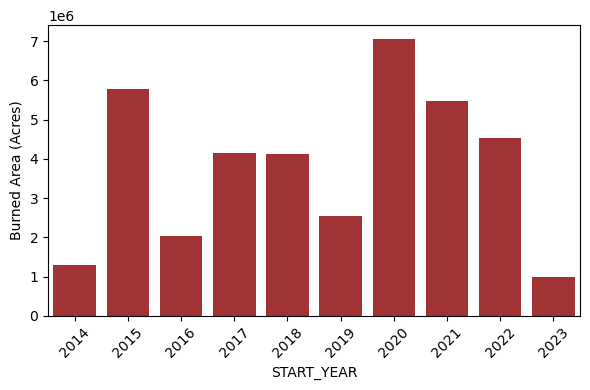

In [3]:
# plot burned area over time
# Group by year and sum burned area (BurnBndAc)
yearly_burn = incis.groupby('START_YEAR', as_index=False)['FINAL_ACRES'].sum()

plt.figure(figsize=(6,4))
sns.barplot(data=yearly_burn, x='START_YEAR', y='FINAL_ACRES', color='firebrick')
plt.xlabel('START_YEAR')
plt.ylabel('Burned Area (Acres)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [4]:
# --- Load the WUMI perimeter dataset
fp = os.path.join(datadir, "wildfire/WUMI2024a/WUMI2024a_main_fires_unified_with_circles.gpkg")
wumi = gpd.read_file(fp)
wumi = wumi[wumi['perimeter_type'] != 'CIRCLE'] # remove the circles
wumi['poly_area_ac'] = wumi['poly_area_ha'] * 2.47105 # make an acres column

# --- Temporal filter
wumi = wumi[(wumi['fire_year'] >= 2004) & (wumi['fire_year'] <= 2023)]

print(wumi.columns)

Index(['fireid', 'dataset', 'agency', 'name', 'date', 'lat', 'lon',
       'poly_area_ha', 'burn_area_ha', 'MTBS_name', 'MTBS_ID', 'IRWINID',
       'FOD_ID', 'FPA_ID', 'object_ID_wfaip', 'object_ID_fpafod',
       'object_ID_wfigs', 'object_ID_calfire', 'object_ID_usgs',
       'object_ID_iafph', 'cause_human_or_natural', 'cause_specific',
       'perimeter_type', 'fire_year', 'geometry', 'poly_area_ac'],
      dtype='object')


In [15]:
wumi['perimeter_type'].unique()

array(['CALFIRE', 'MTBS', 'IAFPH', 'WFIGS'], dtype=object)

In [6]:
# establish connection with the TWIG
twig_url = 'https://gis.reshapewildfire.org/arcgis/rest/services/Hosted/Treatment_Index_and_Intersections/FeatureServer/'

# get the CRS
s_info = requests.get(twig_url + '?f=pjson').json()  # json metadata
srn = s_info['spatialReference']['wkid']  # spatial reference
srn = 'EPSG:' + str(srn)
del s_info

# reproject the fire data to match the TWIG
# fix invalid geometries first
incis['geometry'] = incis['geometry'].buffer(0)
incis = incis[~incis.is_empty & incis.is_valid]
incis = incis.to_crs(srn) # match TWIG
# buffer fire perimeters by 1km
incis['geometry'] = incis.geometry.buffer(1000)

# map over fire events
trt_overlap = {} # to store the results
fire_overlap = {} # to store historic fire perimeter data from NIFC
# map over fire perimeters, extract treatments within a distance
for idx, row in tqdm(incis.iterrows(), total=incis.shape[0], desc='Processing Fires'):
    incis_id = row['INCIDENT_ID']
    fire_name = row['INCIDENT_NAME']
    ig_date = row['DISCOVERY_DATE']

    # get the fire for later
    perim = incis[incis['INCIDENT_ID'] == incis_id][['INCIDENT_ID','geometry']]
    perim = perim.to_crs(srn)

    try:

        # ---- Treatments ----
        # build the query for dates
        end_date = ig_date.strftime('%Y-%m-%d')
        start_date = (ig_date - pd.DateOffset(years=10)).strftime('%Y-%m-%d')
        qry = (f"(treatment_date BETWEEN DATE '{start_date}' AND DATE '{end_date}' "
               f"OR actual_completion_date BETWEEN DATE '{start_date}' AND DATE '{end_date}')")

        # query the TWIG within bounds and for the correct years
        twig = get_feature_service_gdf(twig_url, qry=qry, geo=row['geometry'], layer=0)
        # intersect with the buffered perimeter
        twig = gpd.sjoin(twig, perim, how="inner", predicate="intersects")
        # store the treatment data if any
        trt_overlap[incis_id] = None if twig.empty else twig

        # ---- Previous Fires ----
        # find overlapping burned area from WUMI
        # format query for fire years
        start_year = (ig_date - pd.DateOffset(years=10)).year
        end_year = ig_date.year - 1 # year previous
        # filter the WUMI to the date range appropriate
        wumi_f = wumi[(wumi['fire_year'] >= start_year) & (wumi['fire_year'] <= end_year)]
        wumi_f = wumi_f.to_crs(perim.crs) # match to perimeter data
        # intersect with the buffered perimeter
        prev_fire = gpd.sjoin(wumi_f, perim, how="inner", predicate="intersects")
        # store the results if any
        fire_overlap[incis_id] = None if prev_fire.empty else prev_fire

    except Exception as e:
        # print(f"Error processing {mtbs_id}: {e}")
        trt_overlap[incis_id] = None  # safe fallback on error
        fire_overlap[incis_id] = None

Processing Fires:   0%|          | 0/4259 [00:00<?, ?it/s]

In [7]:
# tidy the TWIG data into one file
# Filter out None values and add a fire name column to each GeoDataFrame
valid_gdfs = []
for inci_id, gdf in trt_overlap.items():
    if gdf is not None and not gdf.empty:
        gdf = gdf.copy()
        gdf['INCIDENT_ID'] = inci_id
        valid_gdfs.append(gdf)

# Concatenate all into a single GeoDataFrame
if valid_gdfs:
    trts_all = gpd.GeoDataFrame(pd.concat(valid_gdfs, ignore_index=True), crs=valid_gdfs[0].crs)
else:
    trts_all = gpd.GeoDataFrame()  # Empty GeoDataFrame if no overlaps found

# Inspect result
print(f"Total treatments found: {len(trts_all)}")

Total treatments found: 76419


In [8]:
trts_all.head()

,geometry,activity,total_cost,type,cost_per_uom,error,fund_code,date_source,uom,identifier_database,...,equipment,activity_code,treatment_date,name,acres,category,SHAPE__Length,objectid,index_right,INCIDENT_ID
0,"POLYGON ((-16735964.459 8538330.835, -16735830...",None,NaN,Thinning,NaN,None,None,act_comp_dt,None,NFPORS,...,None,None,1537056000000,AKKNR-FY18-MX-EastForkRxPrep,4.713520,Mechanical,7757.828308,744928,29,2019_10665633_SWAN LAKE
1,"MULTIPOLYGON (((-16739341.72 8544375.334, -167...",None,NaN,Mastication,NaN,None,None,act_comp_dt,None,NFPORS,...,None,None,1551657600000,AKKNR-FY19-MX-EastForkRxPrep,21.531993,Mechanical,17981.000360,750337,29,2019_10665633_SWAN LAKE
2,"POLYGON ((-16713495.1 8495038.26, -16713491.46...",None,NaN,Hand Pile Burn,NaN,None,None,act_comp_dt,None,NFPORS,...,None,None,1542585600000,AKKNR-FY19-RX-RefugeCabinsDefensibleSpace-Doro...,1.173396,Fire,608.380292,751688,29,2019_10665633_SWAN LAKE
3,"MULTIPOLYGON (((-16735833.123 8538381.947, -16...",None,NaN,Hand Pile Burn,NaN,None,None,act_comp_dt,None,NFPORS,...,None,None,1537747200000,Sterling pile burn 2018,30.485169,Fire,39037.646712,755364,29,2019_10665633_SWAN LAKE
4,"POLYGON ((-16754902.291 8526933.383, -16753871...",None,NaN,Thinning,NaN,None,None,act_comp_dt,None,NFPORS,...,None,None,1537056000000,AKKNR-FY18-MX-EastForkRxPrep,1.401910,Mechanical,2331.101852,758821,29,2019_10665633_SWAN LAKE


In [9]:
trts_all.columns

Index(['geometry', 'activity', 'total_cost', 'type', 'cost_per_uom', 'error',
       'fund_code', 'date_source', 'uom', 'identifier_database', 'fund_source',
       'state', 'SHAPE__Area', 'unique_id', 'actual_completion_date', 'method',
       'agency', 'date_current', 'twig_category', 'equipment', 'activity_code',
       'treatment_date', 'name', 'acres', 'category', 'SHAPE__Length',
       'objectid', 'index_right', 'INCIDENT_ID'],
      dtype='object')

In [10]:
# save the treatment data out
out_fp = os.path.join(projdir, 'data/spatial/treatments/twig_treatments_1km.gpkg')
os.makedirs(os.path.dirname(out_fp), exist_ok=True)
trts_all.to_file(out_fp)
print(f"Saved to: {out_fp}")

Saved to: /Users/mcc/Library/CloudStorage/Box-Box/MCC/projects/ReSHAPE/valuation/data/spatial/treatments/twig_treatments_1km.gpkg


In [11]:
# tidy the NIFC data into one file
# filter out None values and add a fire name column to each GeoDataFrame
valid_gdfs = []
for inci_id, gdf in fire_overlap.items():
    if gdf is not None and not gdf.empty:
        gdf = gdf.copy()
        gdf['INCIDENT_ID'] = inci_id
        valid_gdfs.append(gdf)

# Concatenate all into a single GeoDataFrame
if valid_gdfs:
    fire_all = gpd.GeoDataFrame(pd.concat(valid_gdfs, ignore_index=True), crs=valid_gdfs[0].crs)
else:
    fire_all = gpd.GeoDataFrame()  # Empty GeoDataFrame if no overlaps found

# Inspect result
print(f"Total wildfires found: {len(fire_all)}")

Total wildfires found: 1596


In [13]:
# save the fire data
out_fp = os.path.join(projdir, 'data/spatial/treatments/previous_burns_1km.gpkg')
os.makedirs(os.path.dirname(out_fp), exist_ok=True)
fire_all.to_file(out_fp)
print(f"Saved to: {out_fp}")

Saved to: /Users/mcc/Library/CloudStorage/Box-Box/MCC/projects/ReSHAPE/valuation/data/spatial/treatments/previous_burns_1km.gpkg
